# Exploration of hormonal receptor genes in Wang et al. developing human neocortex dataset - Metacell calculation by SeaCells (only first trimester)

[Reference paper](https://doi.org/10.1038/s41586-024-08351-7)

__Upstream Steps__

* Assemble adata
* QC filter on cells; Expression filter on genes
* Filter by only first trimester cells
* Normalization and log10 transformation by Scanpy functions
* Feature selection (HVG) by Scanpy functions
* Dimensionality reduction
* Cluster identification
* Batch correction by harmony


__This Notebook__

Metacell calculation by SEACells (following [this tutorial](https://github.com/dpeerlab/SEACells/blob/main/notebooks/SEACell_computation.ipynb))


-----

# 1. Environment

## 1.1 Modules

In [1]:
import os
import sys

import numpy as np
import pandas as pd
import scanpy as sc

import pickle

#Plotting
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

#utils
#import ipynbname
from datetime import datetime

# SeaCell
import SEACells

#import custom functions
sys.path.append('../')
import functions as fn

In [2]:
# Some plotting aesthetics
%matplotlib inline

sns.set_style('ticks')
matplotlib.rcParams['figure.figsize'] = [3.5, 3.5]
matplotlib.rcParams['figure.dpi'] = 100

In [3]:
print("Scanpy version: ", sc.__version__)
print("Pandas version: ", pd.__version__)
print("SEACell version: ", SEACells.__version__)

Scanpy version:  1.10.2
Pandas version:  2.2.2
SEACell version:  0.3.3


## 1.2 Settings


In [4]:
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=80)

## 1.3 Files and parameters

In [5]:
input_file = '../../../../DataDir/ExternalData/SingleCellData/Wang_ITrimester_adata.h5ad'
output_file = '../../../../DataDir/ExternalData/SingleCellData/Wang_ITrimester_adataMetacells.h5ad'

## 1.4 Start computations

In [6]:
print(datetime.now())

2026-03-11 12:28:25.280218


----

# 2. Data Load


## 2.1 Read adata file

* SEACells uses as input filtered unnormalized counts from scRNASeq data, that are subjected to normalization and log-transformation before metacell assignment
* Here we start from data that has already undergone the steps of QC, filtering, normalization, log transformation
* The sum of expression levels from cells to metacells will occur at the count level  

In [7]:
adata = sc.read(input_file)

In [8]:
adata

AnnData object with n_obs × n_vars = 23137 × 20266
    obs: 'Auth_Sample_ID', 'Auth_Estimated_postconceptional_age_in_days', 'Auth_Group', 'Auth_Region', 'Auth_nCount_RNA', 'Auth_nFeature_RNA', 'Auth_ATAC_fragments_in_peaks', 'Auth_Scrublet_doublet_score', 'Auth_S.Score', 'Auth_G2M.Score', 'Auth_Class', 'Auth_Subclass', 'Auth_Type_updated', 'Auth_Cluster', 'Auth_cell_type_ontology_term_id', 'Auth_development_stage_ontology_term_id', 'Auth_donor_id', 'Auth_cell_type', 'Auth_sex', 'Auth_tissue', 'Auth_self_reported_ethnicity', 'Auth_development_stage', 'dataset_id', 'sample_id', 'age', 'stage', 'cell_label', 'brain_region', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'log1p_gene_UMI_ratio', 'n_genes', 'n_counts', 'Leiden_02', 'Leiden_04', 'Leiden_06', 'Leiden_Sel'
    var: 'gene_name', 'feature_is_filtered', 'featu

In [9]:
adata.obsm

AxisArrays with keys: X_draw_graph_fa_harmony, X_pca, X_pca_harmony, X_umap_harmony, X_umap_nocorr

In [10]:
adata.X

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 56309487 stored elements and shape (23137, 20266)>

In [11]:
print(adata.X[40:45, 40:45])

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 1 stored elements and shape (5, 5)>
  Coords	Values
  (0, 4)	1.2090129852294922


In [12]:
adata.layers['counts']

<Compressed Sparse Row sparse matrix of dtype 'uint16'
	with 56309487 stored elements and shape (23137, 20266)>

In [13]:
print(adata.layers['counts'][40:45, 40:45])

<Compressed Sparse Row sparse matrix of dtype 'uint16'
	with 1 stored elements and shape (5, 5)>
  Coords	Values
  (0, 4)	1


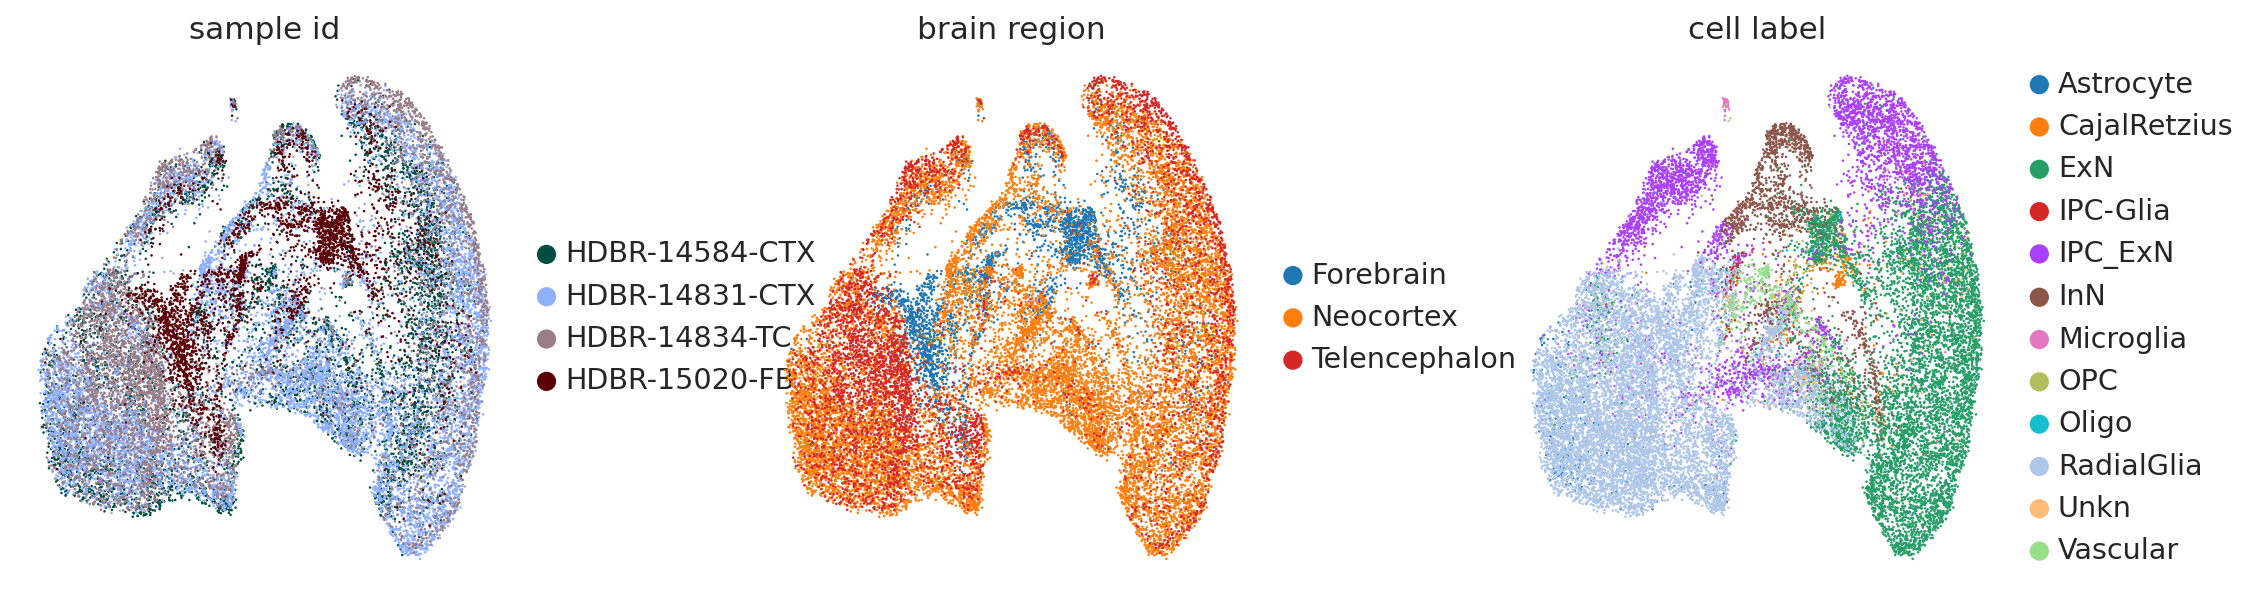

In [14]:
sc.pl.scatter(adata, basis='umap_nocorr', color=['sample_id', 'brain_region', 'cell_label'], frameon=False)

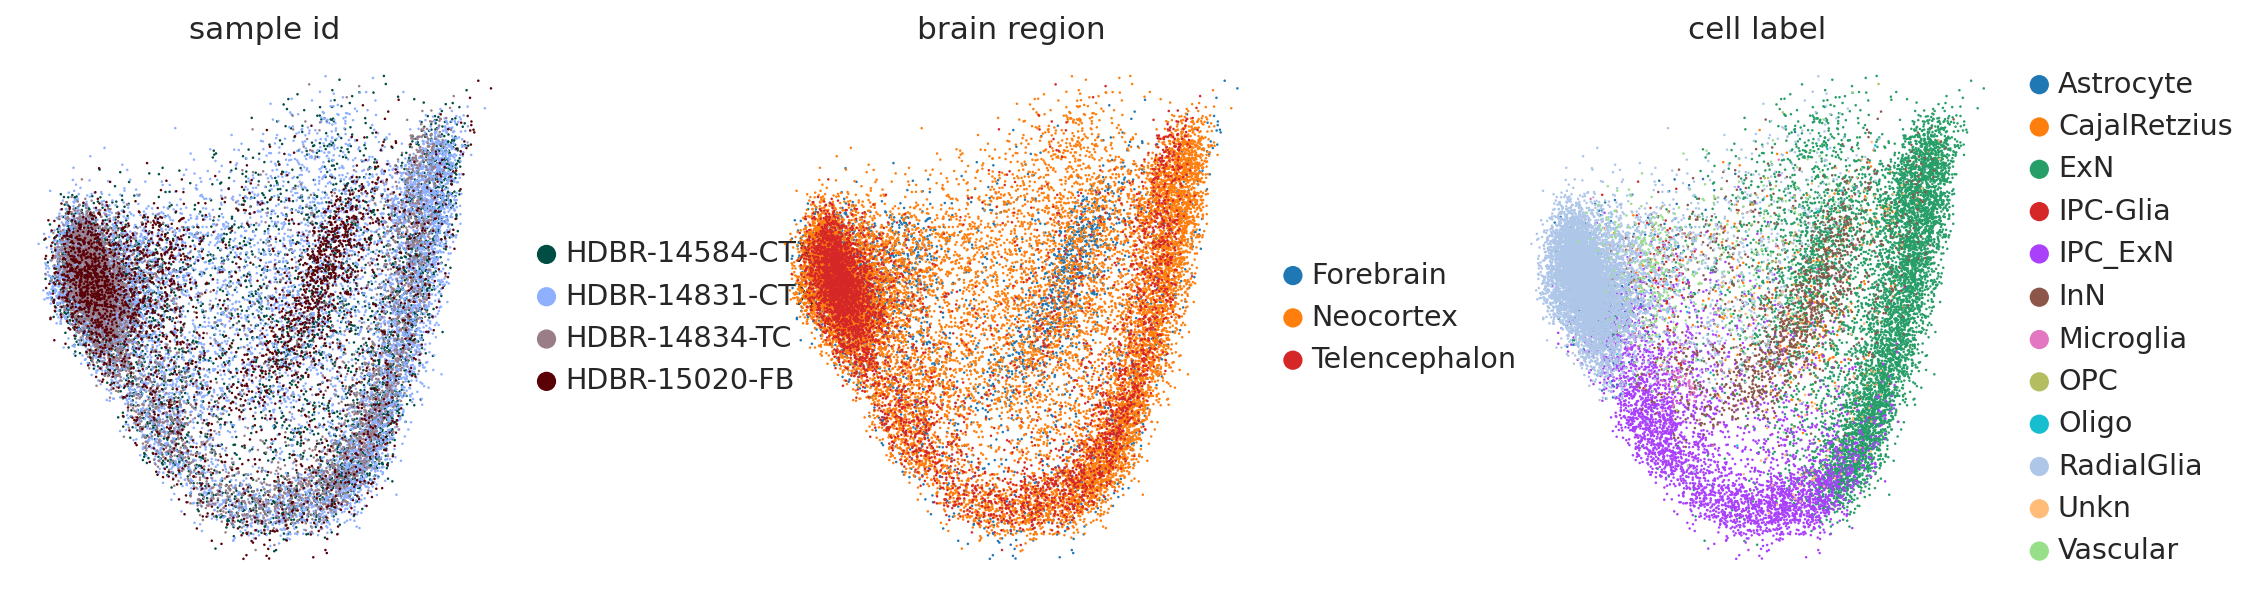

In [15]:
sc.pl.scatter(adata, basis='pca_harmony', color=['sample_id', 'brain_region', 'cell_label'], frameon=False)

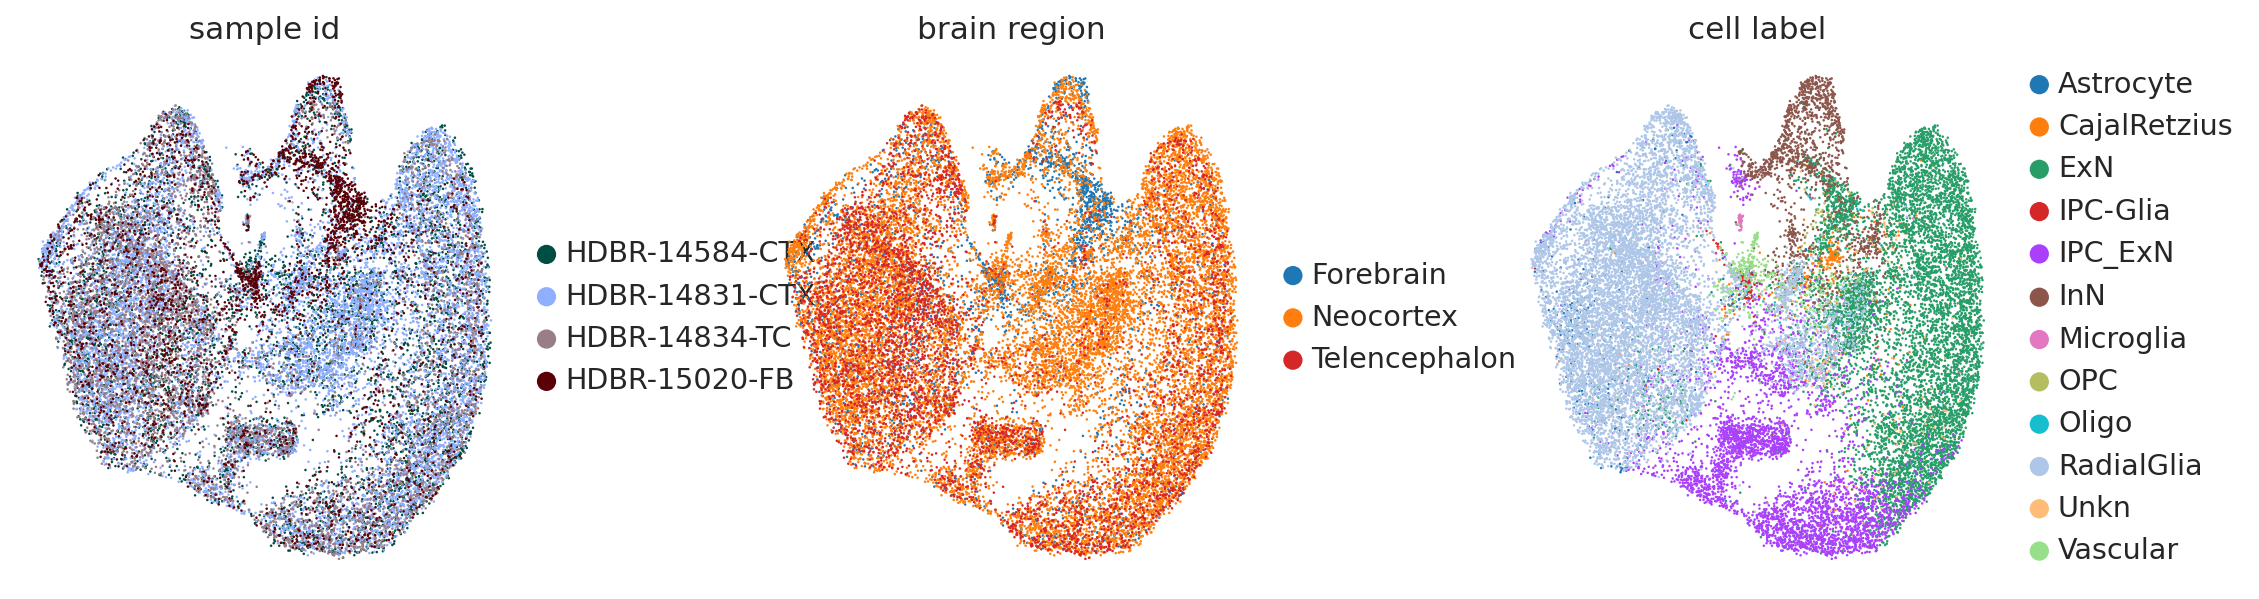

In [16]:
sc.pl.scatter(adata, basis='umap_harmony', color=['sample_id', 'brain_region', 'cell_label'], frameon=False)

In [17]:
adata.obs.head(3)

,Auth_Sample_ID,Auth_Estimated_postconceptional_age_in_days,Auth_Group,Auth_Region,Auth_nCount_RNA,Auth_nFeature_RNA,Auth_ATAC_fragments_in_peaks,Auth_Scrublet_doublet_score,Auth_S.Score,Auth_G2M.Score,...,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,log1p_gene_UMI_ratio,n_genes,n_counts,Leiden_02,Leiden_04,Leiden_06,Leiden_Sel
HDBR-14584-CTX_AAACAGCCATAAGCAA-1,HDBR-14584-CTX,60,First_trimester,General,3095,1510,1173,0.022056,-0.163720,-0.239870,...,131,4.882802,4.232633,0.397355,1510,3095,2,1,1,1
HDBR-14584-CTX_AAACAGCCATCCCTCA-1,HDBR-14584-CTX,60,First_trimester,General,3508,1901,2148,0.047426,-0.124941,-0.279074,...,189,5.247024,5.396916,0.433250,1899,3502,6,8,5,8
HDBR-14584-CTX_AAACAGCCATTAGGTT-1,HDBR-14584-CTX,60,First_trimester,General,4783,2187,3382,0.094412,-0.099038,-0.237593,...,235,5.463832,4.913234,0.376547,2187,4783,5,3,8,3


## 2.2 Pre-processing

Normalization, log-transformation, HVG and dimensionality reduction have been already performed.

# 3. Run SEACells

We follow the workflow described in the [SEACells tutorial](https://github.com/dpeerlab/SEACells/blob/main/notebooks/SEACell_computation.ipynb)



## 3.1 Define parameters

Parameters to be defined: 

* __Number of metacells__ (graining level): choosing one metacell for every 75 single-cells.
* __X_pca_harmony__ as the key in .obsm for computing in metacells. PCs already corrected by harmony.
* __Number of eigenvalues__ for metacell initialization

We then employ the __SEACells.core.SEACells__ function to initialize the model. 

In [18]:
## Core parameters 
n_SEACells = round(adata.n_obs/75)
print(n_SEACells)

build_kernel_on = 'X_pca_harmony' # key in ad.obsm to use for computing metacells
                          # This would be replaced by 'X_svd' for ATAC data

## Additional parameters
n_waypoint_eigs = 10 # Number of eigenvalues to consider when initializing metacells

308


In [19]:
#help(SEACells.core.SEACells)

model = SEACells.core.SEACells(adata, 
                  build_kernel_on=build_kernel_on, 
                  n_SEACells=n_SEACells, 
                  n_waypoint_eigs=n_waypoint_eigs,
                  convergence_epsilon = 1e-5,
                  use_gpu=True)

Welcome to SEACells GPU!


## 3.2 Construct kernel matrix 

[__construct_kernel_matrix__](https://github.com/dpeerlab/SEACells/blob/main/SEACells/cpu.py) function constructs the kernel matrix from data matrix using PCA/SVD and nearest neighbors. Key parameters are: 

* n_neighbors: (int) number of nearest neighbors to use for graph construction (default 15). Increasing this number results in a more homogeneous distribution of metacell size, but may impact on the preservation of rare cell types. Usually stable performance in the range 5-30. 
* graph_construction: method for graph construction.

In [20]:
model.construct_kernel_matrix(n_neighbors=20)
M = model.kernel_matrix

Computing kNN graph using scanpy NN ...
computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:27)
Computing radius for adaptive bandwidth kernel...


  0%|          | 0/23137 [00:00<?, ?it/s]

Making graph symmetric...
Parameter graph_construction = union being used to build KNN graph...
Computing RBF kernel...


  0%|          | 0/23137 [00:00<?, ?it/s]

Building similarity LIL matrix...


  0%|          | 0/23137 [00:00<?, ?it/s]

Constructing CSR matrix...


## 3.3 Initialize archetypes

* [__initialize_archetypes__](https://github.com/dpeerlab/SEACells/blob/main/SEACells/cpu.py) function initializes the B matrix which defines cells as SEACells.
* The function uses waypoint analysis for initialization into to fully cover the phenotype space, and then greedily selects the remaining cells.


In [21]:
# Initialize archetypes
model.initialize_archetypes()

Building kernel on X_pca_harmony
Computing diffusion components from X_pca_harmony for waypoint initialization ... 
computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:05)
Done.
Sampling waypoints ...
Done.
Selecting 296 cells from waypoint initialization.
Initializing residual matrix using greedy column selection
Initializing f and g...


100%|██████████| 22/22 [00:00<00:00, 24.63it/s]

Selecting 12 cells from greedy initialization.


In [22]:
adata

AnnData object with n_obs × n_vars = 23137 × 20266
    obs: 'Auth_Sample_ID', 'Auth_Estimated_postconceptional_age_in_days', 'Auth_Group', 'Auth_Region', 'Auth_nCount_RNA', 'Auth_nFeature_RNA', 'Auth_ATAC_fragments_in_peaks', 'Auth_Scrublet_doublet_score', 'Auth_S.Score', 'Auth_G2M.Score', 'Auth_Class', 'Auth_Subclass', 'Auth_Type_updated', 'Auth_Cluster', 'Auth_cell_type_ontology_term_id', 'Auth_development_stage_ontology_term_id', 'Auth_donor_id', 'Auth_cell_type', 'Auth_sex', 'Auth_tissue', 'Auth_self_reported_ethnicity', 'Auth_development_stage', 'dataset_id', 'sample_id', 'age', 'stage', 'cell_label', 'brain_region', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'log1p_gene_UMI_ratio', 'n_genes', 'n_counts', 'Leiden_02', 'Leiden_04', 'Leiden_06', 'Leiden_Sel'
    var: 'gene_name', 'feature_is_filtered', 'featu

In [23]:
adata.obsm['X_umap'] = adata.obsm['X_umap_harmony'].copy()

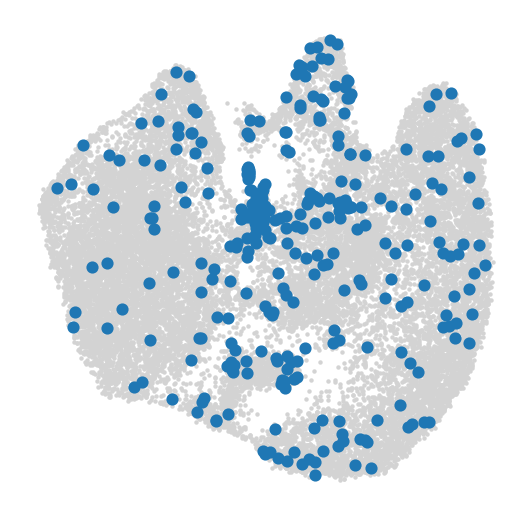

In [24]:
# Plot the initilization to ensure they are spread across phenotypic space
SEACells.plot.plot_initialization(adata, model)

## 3.4 Fit Model

We apply the __model.fit__ function. 

In [25]:
model.fit(min_iter=10, max_iter=50)
model

Randomly initialized A matrix.
Setting convergence threshold at 0.00315
Starting iteration 1.
Completed iteration 1.
Starting iteration 10.
Completed iteration 10.
Starting iteration 20.
Completed iteration 20.
Converged after 29 iterations.


## 4. Access SEACells results 

### 4.1 Check model convergence

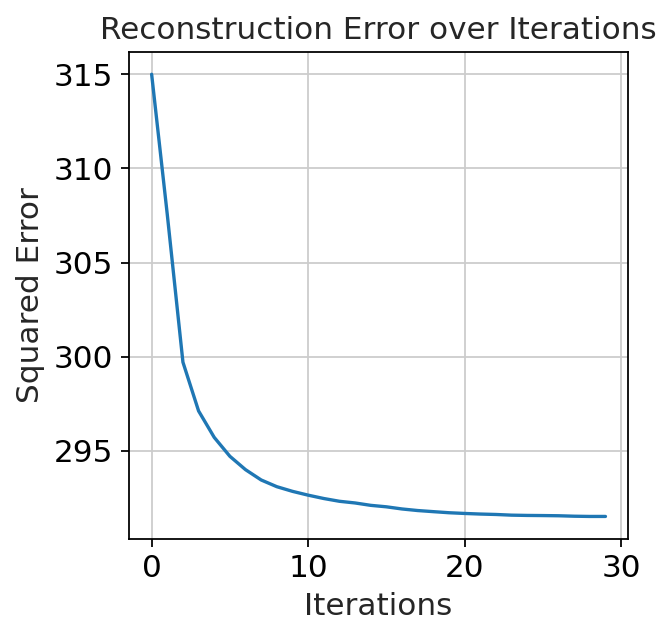

In [26]:
# Plot model convergence
model.plot_convergence()

### 4.2 Inspect SEACells soft assignment

* SEACells analysis returns soft assignments of cells to SEACells (full assignment matrix can be accessed at model.A_)
* The majority of single-cells are assigned to no more than 4 archetypes with non-trivial weight
* The algorithm returns the top 5 metacell assignments as well as the corresponding assignment weights in the function __model.get_soft_assignments()__


/tmp/ipykernel_136029/2880491417.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot((model.A_.T > 0.1).sum(axis=1), kde=False)


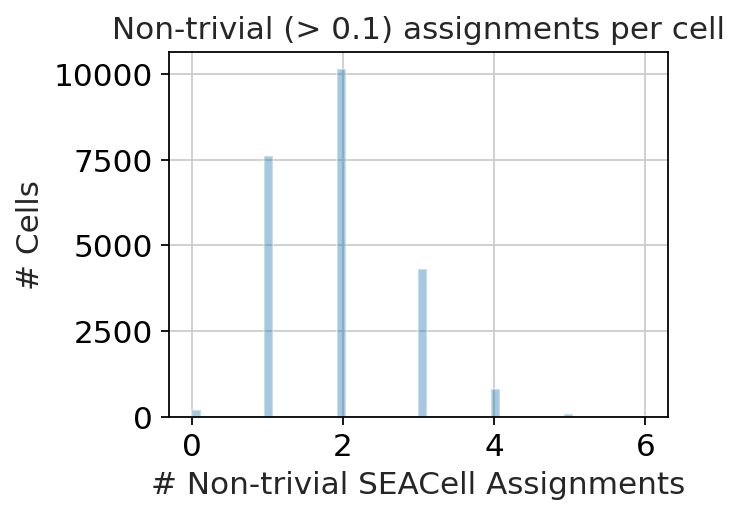

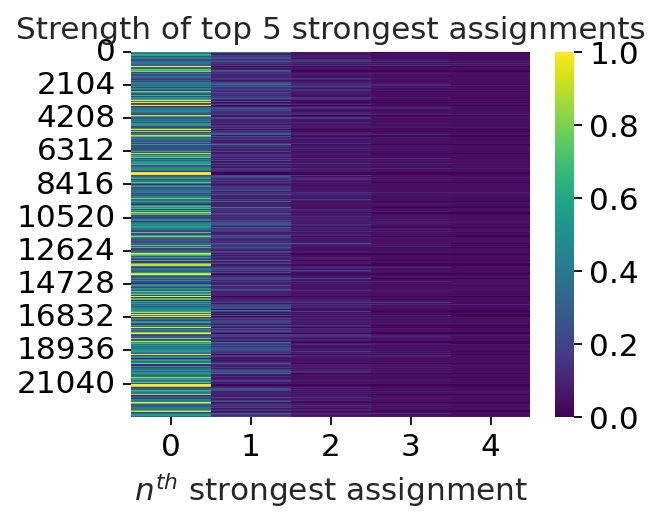

In [27]:
#model.A_

plt.figure(figsize=(4,3))
sns.distplot((model.A_.T > 0.1).sum(axis=1), kde=False)
plt.title(f'Non-trivial (> 0.1) assignments per cell')
plt.xlabel('# Non-trivial SEACell Assignments')
plt.ylabel('# Cells')
plt.show()

plt.figure(figsize=(4,3))
b = np.partition(model.A_.T, -5)    
sns.heatmap(np.sort(b[:,-5:])[:, ::-1], cmap='viridis', vmin=0)
plt.title('Strength of top 5 strongest assignments')
plt.xlabel('$n^{th}$ strongest assignment')
plt.show()

In [28]:
labels,weights = model.get_soft_assignments()
#labels.head()

### 4.3 Inspect and retrieve SEACells hard assignment

We will use hard assignment of each cell to a single metacell to define our metacells for downstream steps. Hard assingment can be retreived in two ways:

* in the modified anndata object in .obs['SEACell']
* from the model using .get_hard_assignments()


In [29]:
adata.obs[['SEACell']].head()

# Alternatively: 
# model.get_hard_assignments().head()

,SEACell
index,
HDBR-14584-CTX_AAACAGCCATAAGCAA-1,SEACell-214
HDBR-14584-CTX_AAACAGCCATCCCTCA-1,SEACell-284
HDBR-14584-CTX_AAACAGCCATTAGGTT-1,SEACell-279
HDBR-14584-CTX_AAACATGCAAAGGTAC-1,SEACell-35
HDBR-14584-CTX_AAACATGCAATAATCC-1,SEACell-37


## 5. Summarizing data by hard assignment

* The original dataset can be summarized by SEACell by aggregating cells within each SEACell, summing over all raw data for all cells belonging to a SEACell.  
* The output of this function is an anndata object of shape n_metacells x original_data_dimension.
* Data is unnormalized and raw aggregated counts are stored in X.
* Attributes associated with variables (.var) are copied over, but relevant per SEACell attributes must be manually copied, since certain attributes may need to be summed, or averaged etc, depending on the attribute.

In [30]:
# By default, ad.raw is used for summarization. Other layers present in the anndata can be specified using the parameter summarize_layer parameter
SEA_adata = SEACells.core.summarize_by_SEACell(adata, SEACells_label='SEACell', summarize_layer='counts', celltype_label='cell_label')
SEA_adata

100%|██████████| 308/308 [00:05<00:00, 55.79it/s]
/env/lib/python3.10/site-packages/anndata/_core/anndata.py:430: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


AnnData object with n_obs × n_vars = 308 × 20266
    obs: 'cell_label', 'cell_label_purity'
    layers: 'raw'

In [31]:
SEA_adata.obs.head()

,cell_label,cell_label_purity
SEACell-214,ExN,0.755906
SEACell-284,RadialGlia,0.934884
SEACell-279,ExN,1.000000
SEACell-35,RadialGlia,0.972678
SEACell-37,OPC,1.000000


In [32]:
print(SEA_adata.X[40:43, 40:43])

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 6 stored elements and shape (3, 3)>
  Coords	Values
  (0, 1)	3.0
  (0, 2)	4.0
  (1, 1)	1.0
  (1, 2)	2.0
  (2, 1)	4.0
  (2, 2)	5.0


## 6. Summarize metadata (for hard assignment)

* Metadata that is available at the cell level can be summarized as an annotation at the metacell level
* Countinous variables are averaged across the cells assigned to each metacell
* Categorical variables are determined by the most prevalent category amongst the cells assigned to the metacell

In [33]:
adata.obs['brain_region']

index
HDBR-14584-CTX_AAACAGCCATAAGCAA-1    Neocortex
HDBR-14584-CTX_AAACAGCCATCCCTCA-1    Neocortex
HDBR-14584-CTX_AAACAGCCATTAGGTT-1    Neocortex
HDBR-14584-CTX_AAACATGCAAAGGTAC-1    Neocortex
HDBR-14584-CTX_AAACATGCAATAATCC-1    Neocortex
                                       ...    
HDBR-15020-FB_TTTGTGAAGTAACCAC-1     Forebrain
HDBR-15020-FB_TTTGTGGCAATACTGT-1     Forebrain
HDBR-15020-FB_TTTGTGGCATAAGGAC-1     Forebrain
HDBR-15020-FB_TTTGTGTTCTCAATTC-1     Forebrain
HDBR-15020-FB_TTTGTTGGTGGATTCA-1     Forebrain
Name: brain_region, Length: 23137, dtype: category
Categories (3, object): ['Forebrain', 'Neocortex', 'Telencephalon']

In [34]:
top_sampleid = adata.obs['sample_id'].groupby(adata.obs['SEACell']).value_counts().groupby(level=0, group_keys=False).head(1) 
SEA_adata.obs['agg_sample_id'] = top_sampleid[SEA_adata.obs_names].index.get_level_values(1)

top_brain_region = adata.obs['brain_region'].groupby(adata.obs['SEACell']).value_counts().groupby(level=0, group_keys=False).head(1)
SEA_adata.obs['Aggregated_brain_region'] = top_brain_region[SEA_adata.obs_names].index.get_level_values(1)

SEA_adata.obs["Auth_Group"] = 'First_trimester'

SEA_adata.obs.head()

,cell_label,cell_label_purity,agg_sample_id,Aggregated_brain_region,Auth_Group
SEACell-214,ExN,0.755906,HDBR-14831-CTX,Neocortex,First_trimester
SEACell-284,RadialGlia,0.934884,HDBR-14831-CTX,Neocortex,First_trimester
SEACell-279,ExN,1.000000,HDBR-14831-CTX,Neocortex,First_trimester
SEACell-35,RadialGlia,0.972678,HDBR-14831-CTX,Neocortex,First_trimester
SEACell-37,OPC,1.000000,HDBR-14831-CTX,Neocortex,First_trimester


## 7. Visualize results

* __plot_2D()__:  visualize metacell assignments on UMAP or any 2-dimensional embedding froma adata.obsm. Plots can also be coloured by metacell assignment. The visualization allows to assess the __representativeness__ of the calculated metacells: ability to represent the global structure of the original dataset. Better representation corresponds to a more uniform coverage of the dataset.

* __plot_SEACell_sizes()__: distribution of number of cells assigned to each metacell. Given to the non-uniform distribution of cell type density, metacells are expected to vary in size: larger metacells are retrieved from denser regions, and smaller metacells from sparser ones. However outlier values may require further inspection. 



/env/lib/python3.10/site-packages/SEACells/plot.py:63: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mcs = umap.groupby("SEACell").mean().reset_index()
/env/lib/python3.10/site-packages/seaborn/relational.py:438: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  points = ax.scatter(x=x, y=y, **kws)
/env/lib/python3.10/site-packages/seaborn/relational.py:438: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  points = ax.scatter(x=x, y=y, **kws)


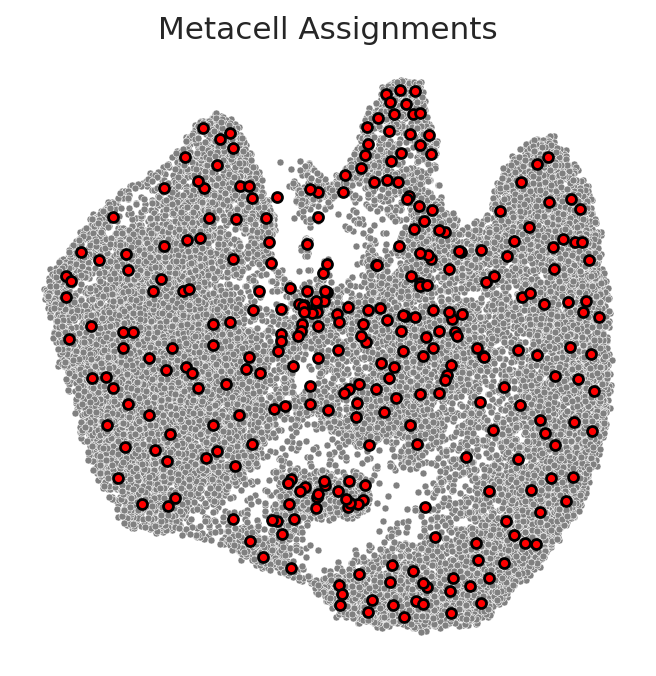

In [35]:
SEACells.plot.plot_2D(adata, key='X_umap', colour_metacells=False)

/env/lib/python3.10/site-packages/SEACells/plot.py:63: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mcs = umap.groupby("SEACell").mean().reset_index()
/env/lib/python3.10/site-packages/seaborn/relational.py:438: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  points = ax.scatter(x=x, y=y, **kws)
/env/lib/python3.10/site-packages/seaborn/relational.py:438: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  points = ax.scatter(x=x, y=y, **kws)


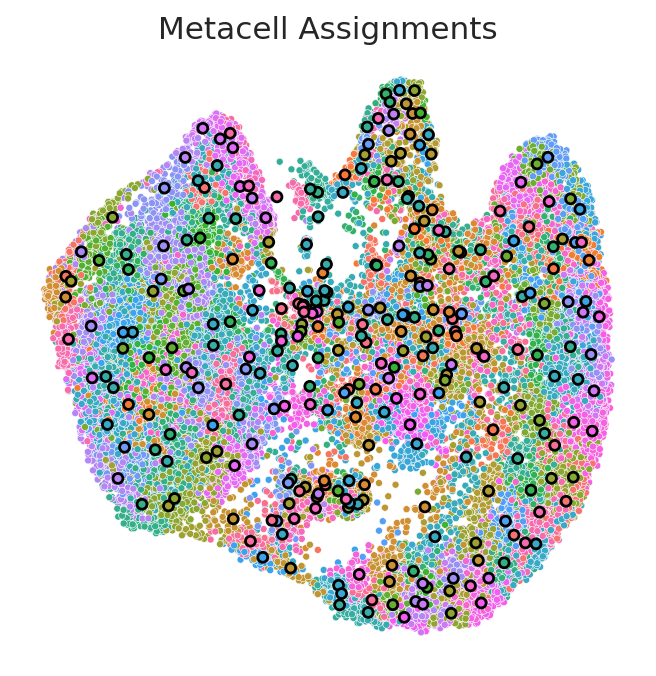

In [36]:
SEACells.plot.plot_2D(adata, key='X_umap', colour_metacells=True)

/env/lib/python3.10/site-packages/SEACells/plot.py:130: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(label_df.groupby("SEACell").count().iloc[:, 0], bins=bins)


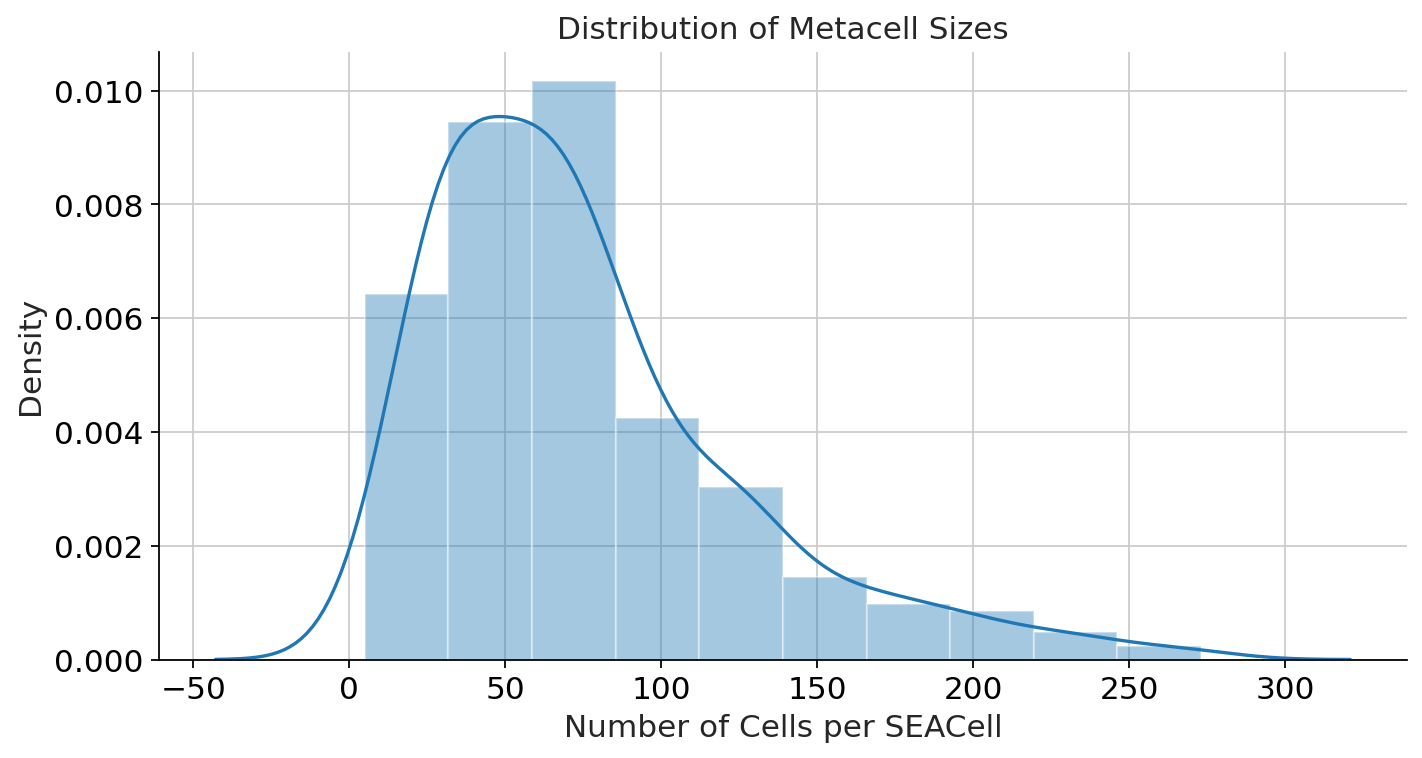

,size
SEACell,
SEACell-0,33
SEACell-1,136
SEACell-10,22
SEACell-100,24
SEACell-101,72
...,...
SEACell-95,73
SEACell-96,91
SEACell-97,36


In [37]:
SEACells.plot.plot_SEACell_sizes(adata, bins=10, figsize=(10, 5))

## 8. Quantifying results

* __Purity__: compute_celltype_purity(ad, col_name) computes the purity of different celltype labels within a SEACell metacell. 
  
* __Compactness__: per-SEAcell variance in diffusion components (typically 'X_pca' for RNA). Lower values of compactness suggest more compact/lower variance metacells.

* __Separation__: distance between a SEACell and its nth_nbr. If cluster is provided as a string, e.g. 'celltype', nearest neighbors are restricted to have the same celltype value. Higher values of separation suggest better distinction between metacells. 

### 8.1 Purity

#### Cell Population

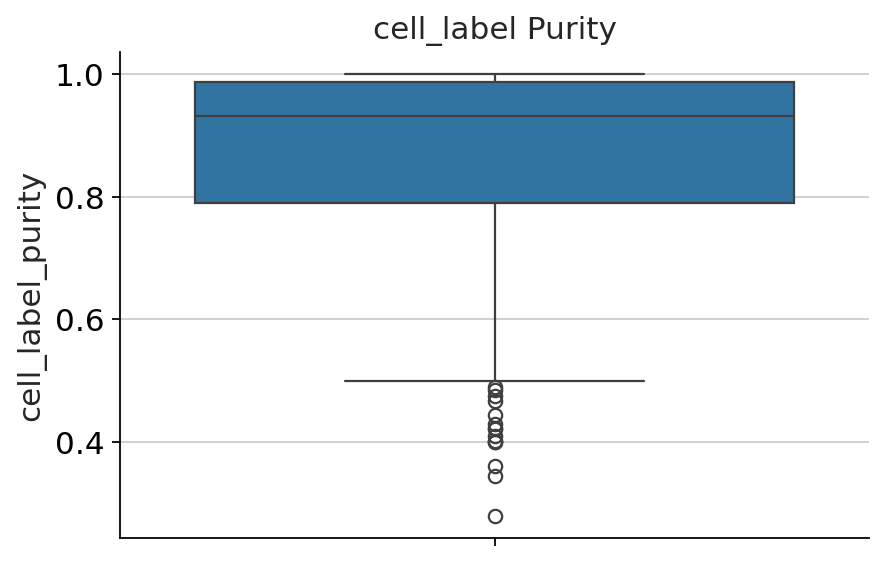

,cell_label,cell_label_purity
SEACell,,
SEACell-0,RadialGlia,0.545455
SEACell-1,ExN,1.000000
SEACell-10,Vascular,0.409091
SEACell-100,CajalRetzius,0.958333
SEACell-101,ExN,0.916667


In [38]:
SEACell_purity = SEACells.evaluate.compute_celltype_purity(adata, 'cell_label')

plt.figure(figsize=(6,4))
sns.boxplot(data=SEACell_purity, y='cell_label_purity')
plt.title('cell_label Purity')
sns.despine()
plt.show()
plt.close()

SEACell_purity.head()

### 8.2 Compactness

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:06)


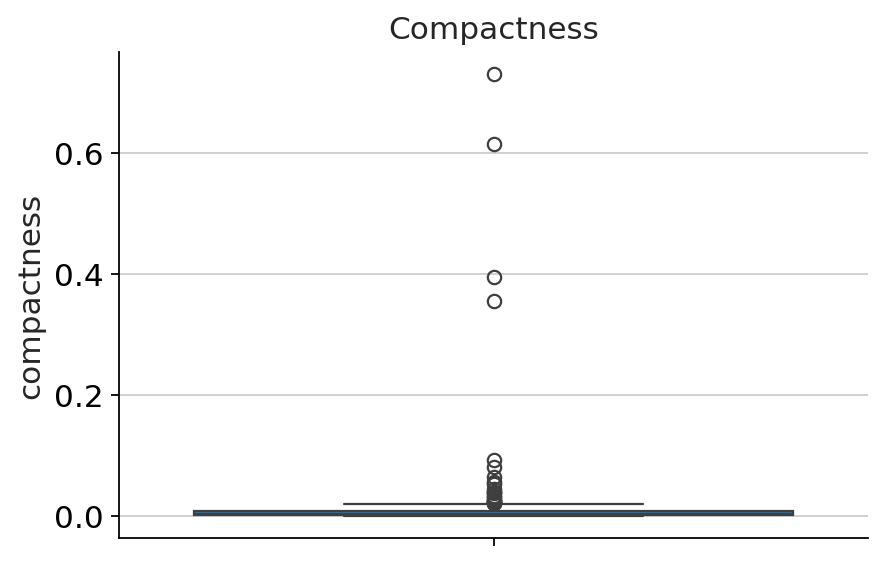

,compactness
SEACell,
SEACell-0,0.012929
SEACell-1,0.000886
SEACell-10,0.040295
SEACell-100,0.003464
SEACell-101,0.003697


In [39]:
compactness = SEACells.evaluate.compactness(adata, 'X_pca_harmony')

plt.figure(figsize=(6,4))
sns.boxplot(data=compactness, y='compactness')
plt.title('Compactness')
sns.despine()
plt.show()
plt.close()

compactness.head()

### 8.3 Separation

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:06)


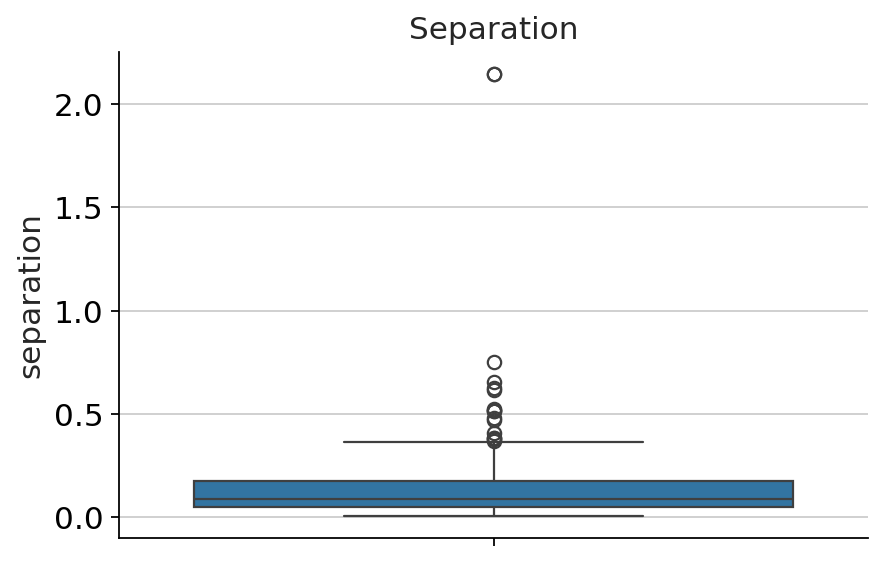

,separation
SEACell,
SEACell-0,0.206783
SEACell-1,0.017085
SEACell-10,0.513386
SEACell-100,0.105930
SEACell-101,0.049692


In [40]:
separation = SEACells.evaluate.separation(adata, 'X_pca_harmony')

plt.figure(figsize=(6,4))
sns.boxplot(data=separation, y='separation')
plt.title('Separation')
sns.despine()
plt.show()
plt.close()

separation.head()

## 9. Hard assignment: downstream processing

* normalization and log-transformation
* dimensionality reduction: PCA and UMAP on SEACells

In [41]:
SEA_adata.layers['counts'] = SEA_adata.X.copy()

sc.pp.normalize_total(SEA_adata)
sc.pp.log1p(SEA_adata)
SEA_adata.layers['lognorm'] = SEA_adata.X.copy()

sc.pp.highly_variable_genes(SEA_adata, inplace=True, batch_key="agg_sample_id")
sc.tl.pca(SEA_adata, use_highly_variable=True)
sc.pp.neighbors(SEA_adata, use_rep='X_pca')
sc.tl.umap(SEA_adata)

normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
computing PCA
    with n_comps=50


/env/lib/python3.10/site-packages/scanpy/preprocessing/_pca.py:385: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  warn(msg, FutureWarning)


    finished (0:00:00)
computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:01)


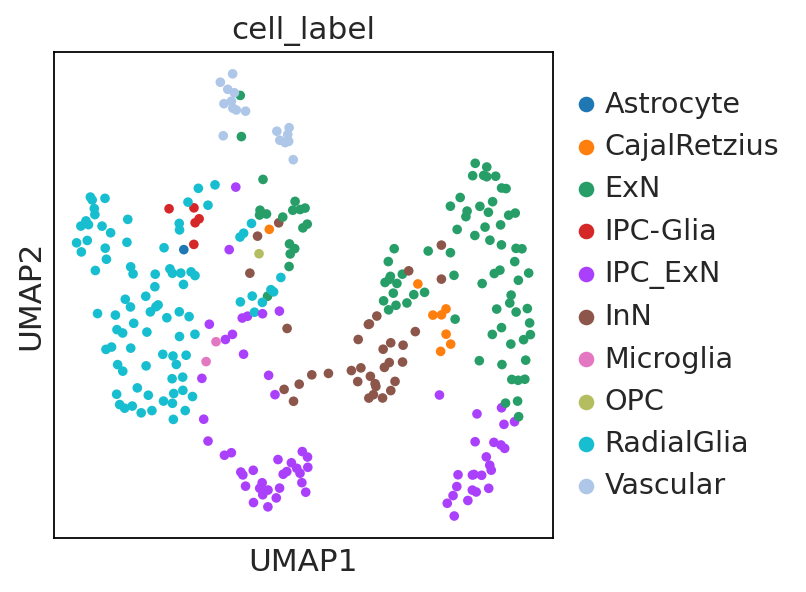

In [42]:
sc.pl.umap(SEA_adata, color=['cell_label'], s=75)

In [43]:
SEA_adata

AnnData object with n_obs × n_vars = 308 × 20266
    obs: 'cell_label', 'cell_label_purity', 'agg_sample_id', 'Aggregated_brain_region', 'Auth_Group'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'cell_label_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'raw', 'counts', 'lognorm'
    obsp: 'distances', 'connectivities'

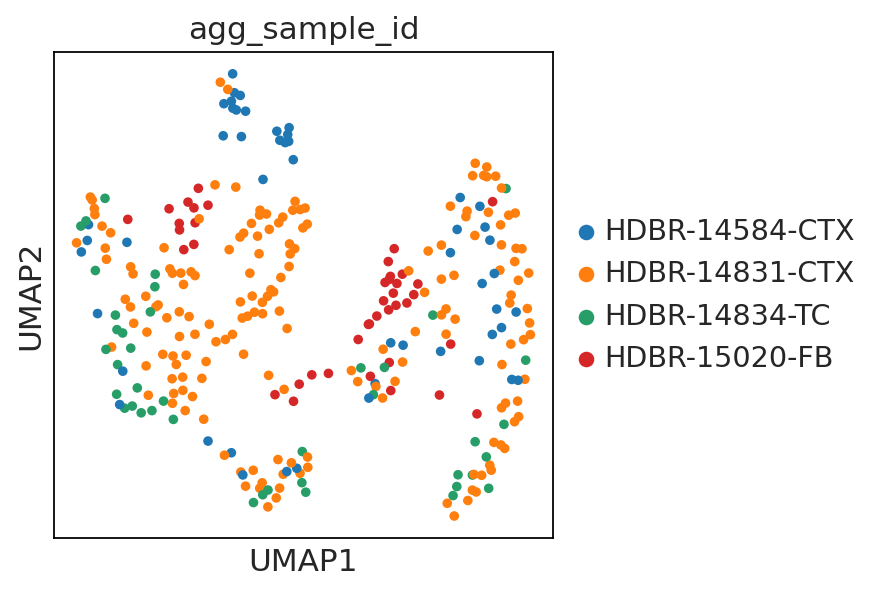

In [44]:
sc.pl.umap(SEA_adata, color=['agg_sample_id'], s=75)

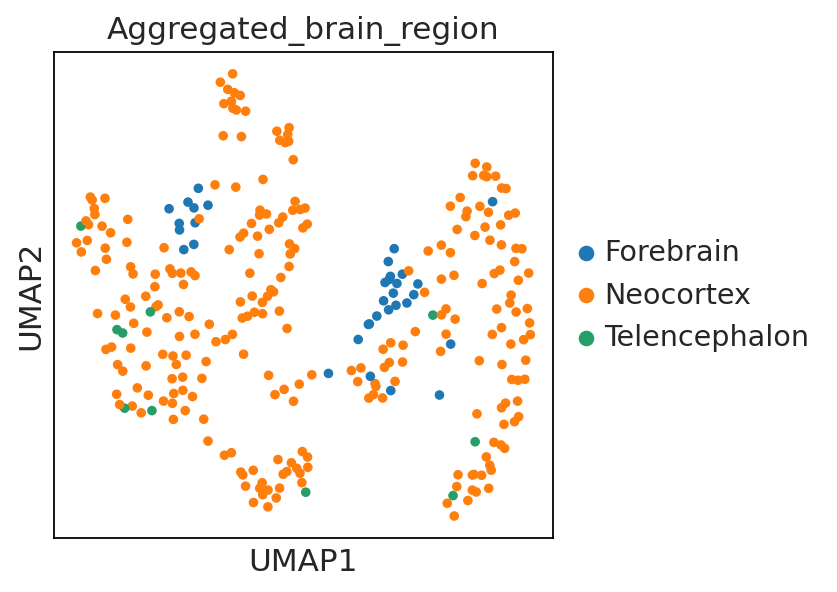

In [45]:
sc.pl.umap(SEA_adata, color=['Aggregated_brain_region'], s=75)

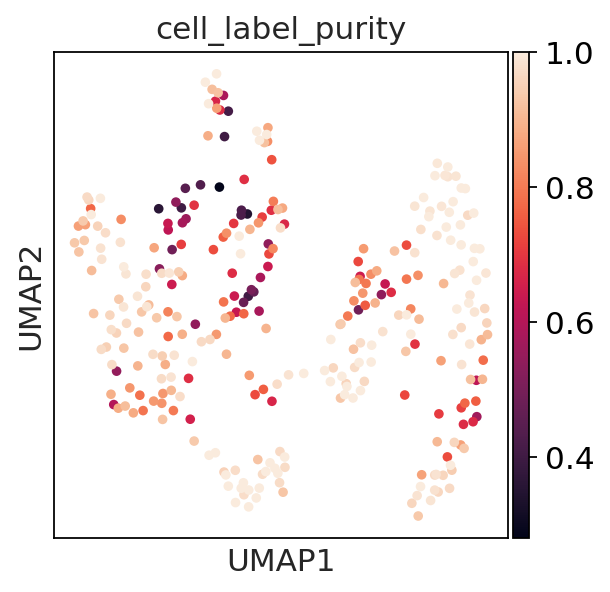

In [46]:
sc.pl.umap(SEA_adata, color=['cell_label_purity'], s=75)

In [47]:
SEA_adata.obs.columns

Index(['cell_label', 'cell_label_purity', 'agg_sample_id',
       'Aggregated_brain_region', 'Auth_Group'],
      dtype='object')

----------------

# 10. Saving

## 10.1 Save SEACell Adata

In [48]:
SEA_adata

AnnData object with n_obs × n_vars = 308 × 20266
    obs: 'cell_label', 'cell_label_purity', 'agg_sample_id', 'Aggregated_brain_region', 'Auth_Group'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'cell_label_colors', 'agg_sample_id_colors', 'Aggregated_brain_region_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'raw', 'counts', 'lognorm'
    obsp: 'distances', 'connectivities'

In [49]:
SEA_adata.X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 4429212 stored elements and shape (308, 20266)>

In [50]:
SEA_adata.write(output_file)

## 10.2 Save in other formats

In [54]:
%%bash

# save also html and python versions for git
jupyter nbconvert SEACellsWang_FirstTrimester.ipynb --to="python" --output="SEACellsWang_FirstTrimester"
jupyter nbconvert SEACellsWang_FirstTrimester.ipynb --to="html" --output="SEACellsWang_FirstTrimester"

[NbConvertApp] Converting notebook SEACellsWang_FirstTrimester.ipynb to python
[NbConvertApp] Writing 13102 bytes to SEACellsWang_FirstTrimester.py
[NbConvertApp] Converting notebook SEACellsWang_FirstTrimester.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 11 image(s).
[NbConvertApp] Writing 6399677 bytes to SEACellsWang_FirstTrimester.html


## 10.3 Finished computations: timestamp

In [55]:
print(datetime.now())

2026-03-11 12:40:04.839718
